# Investment Strategy Backtester

This notebook demonstrates and compares several investment strategies using historical market data.

The strategies tested are:
- Random Selection
- Biggest Growers
- Momentum
- Mean Reversion

The notebook evaluates each strategy using measures of return and risk, before using in-sample parameter selection and out-of-sample testing to compare the strategies against the SPY benchmark.

In [1]:
from strategies import (
    random_stock_selection,
    biggest_growers,
    momentum_strat,
    mean_reversion
)

from portfolio import Analysis
from market_data import weekly
import matplotlib.pyplot as plt
import numpy as np

## Strategy Comparison

The following section compares the different strategies over the same historical period. Each strategy begins with the same initial portfolio value and includes estimated transaction costs.

In [2]:
start = 27

np.random.seed(42)

random = random_stock_selection(n=20, start=start, name="Random Selection")
growers = biggest_growers(n=20, start=start, name="Biggest Growers")
momentum = momentum_strat(t=26,n=20, start=start, name="Momentum")
mean_rev = mean_reversion(t=4,n=20, start=start, name="Mean Reversion")

,Total Return,Annualised Return,Volatility,Sharpe Ratio,Max Drawdown
Random Selection,0.420025,0.081334,0.153628,0.584196,-0.292587
Biggest Growers,0.205426,0.042541,0.172800,0.326229,-0.366038
Momentum,0.874427,0.150392,0.177076,0.877940,-0.185182
Mean Reversion,0.888956,0.152374,0.199815,0.807051,-0.232759


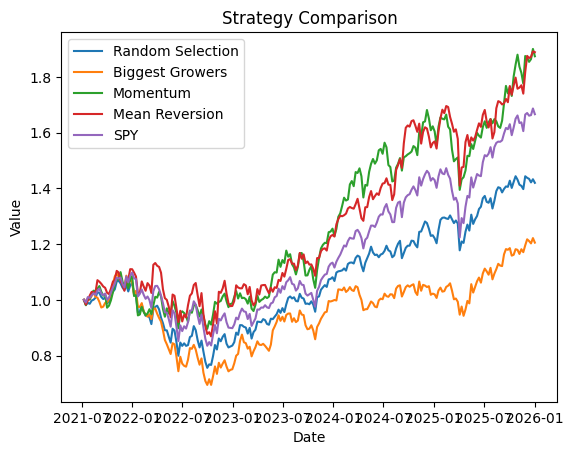

In [3]:
strategies = Analysis([random, growers, momentum, mean_rev])

display(strategies.summary())
strategies.plot()

## Momentum Parameter Selection

The momentum strategy depends on two main parameters:

- `t`: the momentum lookback period in weeks
- `n`: the number of stocks held in the portfolio

To avoid selecting parameters based on the test data, combinations of `t` and `n` are evaluated using only the 2021–2024 training period. The combination with the highest Sharpe ratio is selected before out-of-sample testing.

In [4]:
training_end = weekly.index.get_loc("2025-01-03")

lookbacks = list(range(2, 27, 2))
portfolio_sizes = [1, 2, 3, 4, 5, 10, 15, 20, 25, 30]

momentum_tests = []

for t in lookbacks:
    for n in portfolio_sizes:
        portfolio = momentum_strat(
            t=t,
            n=n,
            start=27,
            end=training_end,
            name=f"Momentum t={t}, n={n}"
        )
        momentum_tests.append(portfolio)

momentum_analysis = Analysis(momentum_tests)
results = momentum_analysis.summary()
results.sort_values("Sharpe Ratio",ascending=False).head(15)

,Total Return,Annualised Return,Volatility,Sharpe Ratio,Max Drawdown
"Momentum t=20, n=1",4.247074,0.612640,0.486254,1.216241,-0.359742
"Momentum t=20, n=3",1.959815,0.367275,0.308230,1.166427,-0.303898
"Momentum t=20, n=2",2.007224,0.373553,0.354368,1.069429,-0.288223
"Momentum t=24, n=2",1.839095,0.350960,0.344016,1.042124,-0.308021
"Momentum t=20, n=4",1.314076,0.273628,0.267124,1.037105,-0.243621
"Momentum t=22, n=1",2.335895,0.415244,0.436186,1.008389,-0.482149
"Momentum t=22, n=4",1.224399,0.259199,0.274481,0.974848,-0.221119
"Momentum t=26, n=25",0.690823,0.163472,0.169970,0.973650,-0.176192
"Momentum t=22, n=2",1.560553,0.311337,0.341577,0.961510,-0.336738
"Momentum t=24, n=3",1.351239,0.279491,0.307963,0.951896,-0.273696


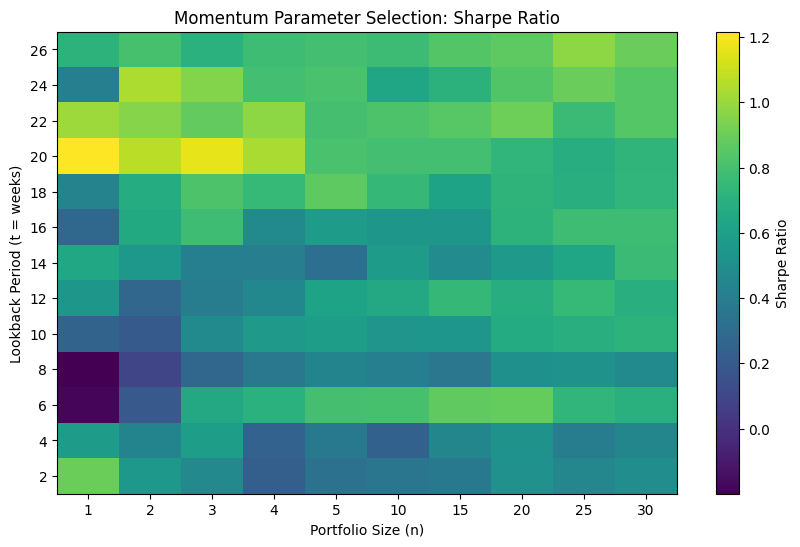

In [5]:
sharpe_values = momentum_analysis.sharpe().values.reshape(
    len(lookbacks), len(portfolio_sizes)
)

plt.figure(figsize=(10, 6))
plt.imshow(sharpe_values, aspect="auto", origin="lower")

plt.xticks(range(len(portfolio_sizes)), portfolio_sizes)
plt.yticks(range(len(lookbacks)), lookbacks)

plt.xlabel("Portfolio Size (n)")
plt.ylabel("Lookback Period (t = weeks)")
plt.title("Momentum Parameter Selection: Sharpe Ratio")

plt.colorbar(label="Sharpe Ratio")
plt.show()

### Momentum Parameter Selection Results

All combinations of lookback periods from 2 to 26 weeks and portfolio sizes from 1 to 30 stocks were evaluated using the 2021–2024 training period.

The combination of a 20-week lookback and a portfolio size of 1 stock produced the highest Sharpe ratio of approximately 1.22 and was therefore selected for out-of-sample testing.

The 20-week lookback also performed strongly across several other portfolio sizes, suggesting that its performance was not limited to a single parameter combination. However, the selected one-stock portfolio is highly concentrated and exhibits relatively high volatility and drawdown.

## Biggest Growers Parameter Selection

The Biggest Growers strategy has one main parameter: the number of stocks held in the portfolio.

Different portfolio sizes are tested using only the 2021–2024 training period. The portfolio size with the highest Sharpe ratio is selected before evaluating the strategy on the out-of-sample period.

In [6]:
portfolio_sizes = [1, 2, 3, 4, 5, 10, 15, 20, 25, 30]

grower_tests = []

for n in portfolio_sizes:
    portfolio = biggest_growers(
        n=n,
        start=27,
        end=training_end,
        name=f"Biggest Growers n={n}"
    )
    grower_tests.append(portfolio)

grower_analysis = Analysis(grower_tests)

display(grower_analysis.summary())

,Total Return,Annualised Return,Volatility,Sharpe Ratio,Max Drawdown
Biggest Growers n=1,0.769277,0.178785,0.401224,0.598951,-0.567295
Biggest Growers n=2,1.019369,0.224581,0.321515,0.785838,-0.517828
Biggest Growers n=3,0.522940,0.128921,0.270136,0.580855,-0.492088
Biggest Growers n=4,0.306877,0.080210,0.236664,0.442190,-0.452761
Biggest Growers n=5,0.120512,0.033346,0.223920,0.257188,-0.488861
Biggest Growers n=10,-0.051649,-0.015171,0.203281,0.025595,-0.434377
Biggest Growers n=15,-0.044634,-0.013077,0.188827,0.024204,-0.400791
Biggest Growers n=20,0.022360,0.006395,0.177894,0.124036,-0.366038
Biggest Growers n=25,0.058343,0.016481,0.172473,0.180145,-0.343035
Biggest Growers n=30,0.106000,0.029470,0.168558,0.255441,-0.320985


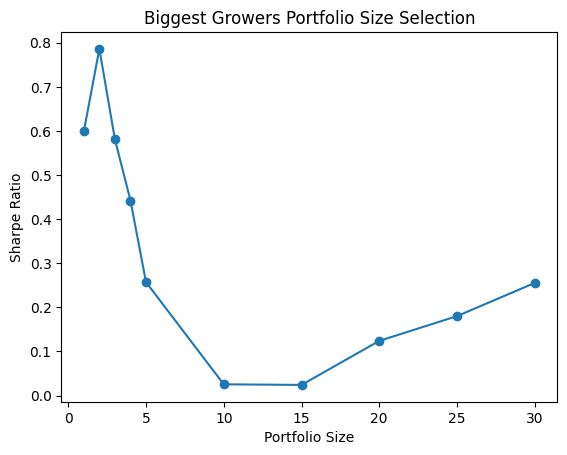

In [7]:
sharpes = grower_analysis.sharpe()

plt.plot(portfolio_sizes, sharpes, marker="o")
plt.xlabel("Portfolio Size")
plt.ylabel("Sharpe Ratio")
plt.title("Biggest Growers Portfolio Size Selection")
plt.show()

### Biggest Growers Portfolio Size Selection

A portfolio size of 2 stocks produced the highest Sharpe ratio during the training period, at approximately 0.79. Therefore, a portfolio size of 2 was selected for the out-of-sample test.

Although smaller portfolios generally produced higher returns, they also experienced substantially greater volatility and drawdowns. The selected portfolio size represents the best risk-adjusted performance according to the predefined Sharpe ratio criterion.

## Mean Reversion Parameter Selection

The Mean Reversion strategy depends on two main parameters: the lookback period and the number of stocks held.

Combinations of these parameters are evaluated using only the 2021–2024 training period. The combination with the highest Sharpe ratio is selected before out-of-sample testing.

In [8]:
mean_rev_tests = []

for t in lookbacks:
    for n in portfolio_sizes:
        portfolio = mean_reversion(
            t=t,
            n=n,
            start=27,
            end=training_end,
            name=f"Mean Reversion t={t}, n={n}"
        )
        mean_rev_tests.append(portfolio)

mean_rev_analysis = Analysis(mean_rev_tests)

results = mean_rev_analysis.summary()
display(results.sort_values("Sharpe Ratio", ascending=False).head(15))

,Total Return,Annualised Return,Volatility,Sharpe Ratio,Max Drawdown
"Mean Reversion t=8, n=15",1.008196,0.222623,0.216903,1.031645,-0.180257
"Mean Reversion t=8, n=10",1.138507,0.244985,0.241047,1.025820,-0.154215
"Mean Reversion t=10, n=15",0.941240,0.210730,0.218791,0.979740,-0.202670
"Mean Reversion t=10, n=20",0.869517,0.197661,0.206868,0.971821,-0.210104
"Mean Reversion t=8, n=20",0.849177,0.193890,0.207365,0.955058,-0.203310
"Mean Reversion t=10, n=10",0.997331,0.220713,0.238791,0.951028,-0.214836
"Mean Reversion t=8, n=30",0.752953,0.175639,0.189439,0.945784,-0.171120
"Mean Reversion t=8, n=25",0.758368,0.176685,0.195322,0.927415,-0.192540
"Mean Reversion t=4, n=30",0.701063,0.165499,0.188374,0.903933,-0.193632
"Mean Reversion t=8, n=5",1.051049,0.230088,0.271457,0.894512,-0.236013


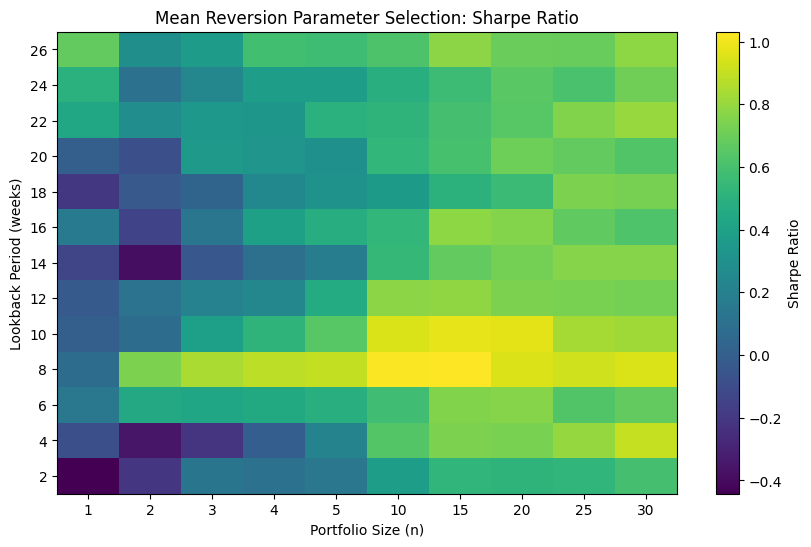

In [9]:
sharpe_values = mean_rev_analysis.sharpe().values.reshape(
    len(lookbacks), len(portfolio_sizes)
)

plt.figure(figsize=(10, 6))
plt.imshow(sharpe_values, aspect="auto", origin="lower")
plt.xticks(range(len(portfolio_sizes)), portfolio_sizes)
plt.yticks(range(len(lookbacks)), lookbacks)

plt.xlabel("Portfolio Size (n)")
plt.ylabel("Lookback Period (weeks)")
plt.title("Mean Reversion Parameter Selection: Sharpe Ratio")

plt.colorbar(label="Sharpe Ratio")
plt.show()

### Mean Reversion Parameter Selection Results

All combinations of the tested lookback periods and portfolio sizes were evaluated using the 2021–2024 training period.

The combination of an 8-week lookback and a portfolio size of 15 stocks produced the highest Sharpe ratio of approximately 1.03 and was therefore selected for out-of-sample testing.

The 8-week lookback also performed strongly across several other portfolio sizes, suggesting that the selected parameters were not an isolated optimum.

## Out-of-Sample Testing

All strategy parameters were selected using only the 2021–2024 training period. The selected parameters are:

- Momentum: 20-week lookback, 1 stock
- Biggest Growers: 2 stocks
- Mean Reversion: 8-week lookback, 15 stocks

These parameters are now fixed and evaluated on the 2025 out-of-sample period. This provides a better indication of how the strategies perform on data that was not used during parameter selection.

In [10]:
test_start = training_end

momentum_test = momentum_strat(
    t=20,
    n=1,
    start=test_start,
    end=len(weekly),
    name="Momentum OOS"
)

test_analysis = Analysis([momentum_test])

display(test_analysis.summary())

,Total Return,Annualised Return,Volatility,Sharpe Ratio,Max Drawdown
Momentum OOS,0.020725,0.0204,0.400591,0.248518,-0.332074


,Total Return,Annualised Return,Volatility,Sharpe Ratio,Max Drawdown
Random Selection,0.042087,0.041421,0.155248,0.338010,-0.166081
Biggest Growers,0.435844,0.427816,0.286227,1.380947,-0.189062
Mean Reversion,0.176888,0.173921,0.205691,0.879138,-0.163653
Momentum,0.020725,0.020400,0.400591,0.248518,-0.332074
SPY,0.159523,0.156866,0.171645,0.932243,-0.168772


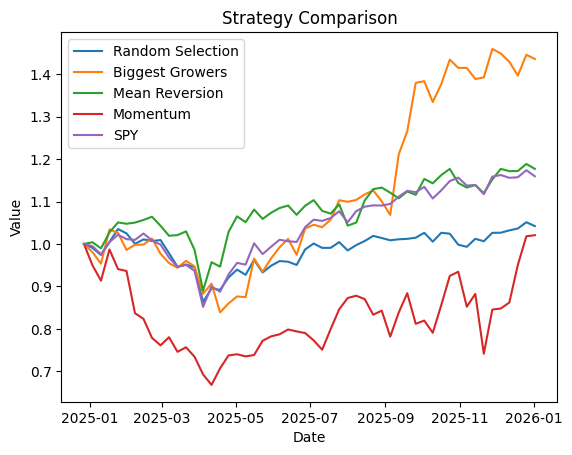

In [11]:
np.random.seed(42)

random_test = random_stock_selection(
    n=20,
    start=test_start,
    end=len(weekly),
    name="Random Selection"
)

growers_test = biggest_growers(
    n=2,
    start=test_start,
    end=len(weekly),
    name="Biggest Growers"
)

mean_rev_test = mean_reversion(
    t=8,
    n=15,
    start=test_start,
    end=len(weekly),
    name="Mean Reversion"
)

momentum_test = momentum_strat(
    t=20,
    n=1,
    start=test_start,
    end=len(weekly),
    name="Momentum"
)

spy_test = Analysis([momentum_test]).benchmark(momentum_test)

oos_all = Analysis([
    random_test,
    growers_test,
    mean_rev_test,
    momentum_test,
    spy_test
])

display(oos_all.summary())
oos_all.plot(benchmark=False)

### Out-of-Sample Results

All strategy parameters were selected using the 2021–2024 training period and fixed before evaluating performance during 2025.

The Biggest Growers strategy performed best, achieving a total return of approximately 43.6% and a Sharpe ratio of 1.38. This substantially outperformed the SPY benchmark, which returned approximately 16.0% with a Sharpe ratio of 0.93.

Mean Reversion returned approximately 17.7%, slightly outperforming SPY on total return. However, its Sharpe ratio of approximately 0.88 was lower than SPY's 0.93. It experienced volatility of approximately 20.6% and a maximum drawdown of approximately 16.4%.

The Momentum strategy performed poorly out of sample, returning approximately 2.1%. It also experienced high volatility of approximately 40.1% and a maximum drawdown of approximately 33.2%, resulting in a Sharpe ratio of approximately 0.25.

Random Selection returned approximately 4.2% with a Sharpe ratio of 0.34, underperforming the systematic strategies other than Momentum and the SPY benchmark.

Overall, the Biggest Growers strategy showed the strongest out-of-sample performance. Mean Reversion slightly exceeded SPY in raw return but not on a risk-adjusted basis, while the strong in-sample performance of Momentum did not persist during the test period. These results cover only a single out-of-sample year and should not be interpreted as evidence that the strategies will continue to perform similarly in the future.